In [121]:
# ============================================================
# IMPORT TẤT CẢ THƯ VIỆN CẦN DÙNG
# ============================================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Scikit-learn — pipeline ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

# Cài đặt hiển thị đẹp hơn
pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

print("✅ Import thành công!")

✅ Import thành công!


In [122]:
# Đọc dữ liệu
# Thay đường dẫn nếu file ở chỗ khác
import pandas as pd

# 1. Nạp file gốc và file tiếng Việt
df_old = pd.read_csv("/home/truong-vu/Downloads/project2/data/Language Detection.csv")
df_vn = pd.read_csv("/home/truong-vu/Downloads/project2/data/vietnamese.csv")

# 2. Xử lý cột thừa (Unnamed) nếu có
df_old = df_old.loc[:, ~df_old.columns.str.contains('^Unnamed')]
df_vn = df_vn.loc[:, ~df_vn.columns.str.contains('^Unnamed')]

# 3. Ép tên cột về cùng một chuẩn (Viết hoa chữ cái đầu)
df_old.columns = ['Text', 'Language']
df_vn.columns = ['Text', 'Language']

# 4. Gộp lại
df = pd.concat([df_old, df_vn], ignore_index=True)

# 5. QUAN TRỌNG: Xóa bỏ mọi dòng bị trống (NaN) để tránh lỗi sorted
df = df.dropna(subset=['Text', 'Language'])

# 6. Chuẩn hóa nhãn 'Vietnamese' (Xóa dấu cách hoặc dấu chấm thừa)
df['Language'] = df['Language'].str.strip().str.replace('.', '', regex=False)


print(f"📊 Kích thước dataset: {df.shape}")
print(f"📋 Các cột: {list(df.columns)}")
# Kiểm tra giá trị null
print("🔍 Giá trị null:")
print(df.isnull().sum())

print(f"\n📌 Số ngôn ngữ trong dataset: {df['Language'].nunique()}")
print(f"📌 Danh sách ngôn ngữ:")
print(sorted(df['Language'].unique()))
df.head(10)

📊 Kích thước dataset: (10737, 2)
📋 Các cột: ['Text', 'Language']
🔍 Giá trị null:
Text        0
Language    0
dtype: int64

📌 Số ngôn ngữ trong dataset: 18
📌 Danh sách ngôn ngữ:
['Arabic', 'Danish', 'Dutch', 'English', 'French', 'German', 'Greek', 'Hindi', 'Italian', 'Kannada', 'Malayalam', 'Portugeese', 'Russian', 'Spanish', 'Sweedish', 'Tamil', 'Turkish', 'Vietnamese']


,Text,Language
0,"Nature, in the broadest sense, is the natural, physical, material world or universe.",English
1,"""Nature"" can refer to the phenomena of the physical world, and also to life in general.",English
2,"The study of nature is a large, if not the only, part of science.",English
3,"Although humans are part of nature, human activity is often understood as a separate category fr...",English
4,[1] The word nature is borrowed from the Old French nature and is derived from the Latin word na...,English
5,"[2] In ancient philosophy, natura is mostly used as the Latin translation of the Greek word phys...",English
6,"[3][4] \nThe concept of nature as a whole, the physical universe, is one of several expansions o...",English
7,"During the advent of modern scientific method in the last several centuries, nature became the p...",English
8,"[5][6] With the Industrial revolution, nature increasingly became seen as the part of reality de...",English
9,"However, a vitalist vision of nature, closer to the presocratic one, got reborn at the same time...",English


In [123]:
# Dùng toàn bộ dataset, không lọc ngôn ngữ
df_filtered = df.copy()
df_filtered = df_filtered.reset_index(drop=True)

SELECTED_LANGUAGES = sorted(df_filtered['Language'].unique().tolist())

print(f"📊 Dataset: {df_filtered.shape}")
print(f"📌 Tổng số ngôn ngữ: {len(SELECTED_LANGUAGES)}")
print("\n📈 Phân phối nhãn:")
print(df_filtered['Language'].value_counts())

📊 Dataset: (10737, 2)
📌 Tổng số ngôn ngữ: 18

📈 Phân phối nhãn:
Language
English       1385
French        1014
Spanish        819
Portugeese     739
Italian        698
Russian        692
Sweedish       676
Malayalam      594
Dutch          546
Arabic         536
Turkish        474
German         470
Tamil          469
Danish         428
Vietnamese     400
Kannada        369
Greek          365
Hindi           63
Name: count, dtype: int64


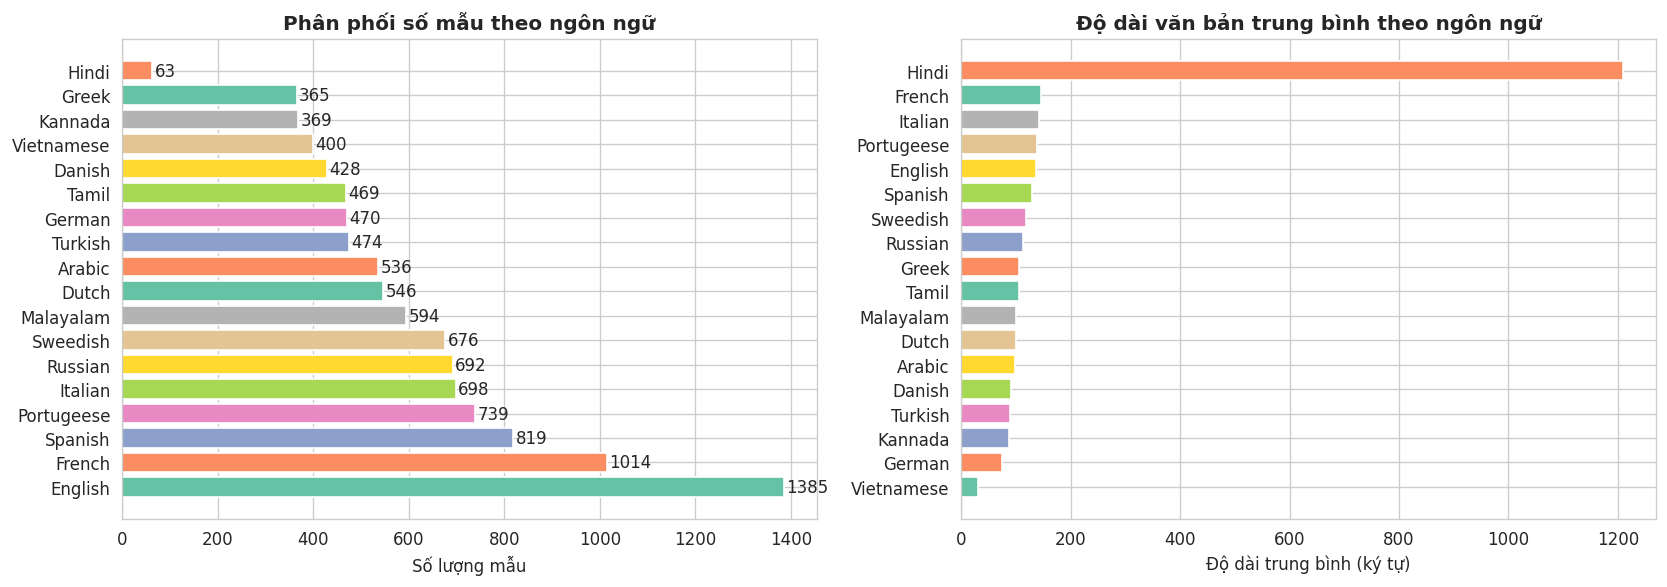


📊 Thống kê độ dài văn bản:
             count    mean     std   min   25%    50%     75%      max
Language                                                              
Arabic       536.0    99.2    81.2   1.0  37.0   80.0   141.0    581.0
Danish       428.0    91.3    87.1   3.0  28.0   68.0   121.2    737.0
Dutch        546.0    99.3    85.1   7.0  32.0   84.0   132.8    759.0
English     1385.0   136.9    83.4   5.0  81.0  124.0   180.0    720.0
French      1014.0   145.1   103.8   5.0  75.0  132.0   194.8   1168.0
German       470.0    74.7    62.8   6.0  28.0   56.0   105.0    455.0
Greek        365.0   106.3    97.1   5.0  28.0   87.0   157.0    733.0
Hindi         63.0  1209.2  2833.6  15.0  45.5  189.0  1376.5  19088.0
Italian      698.0   142.2   117.0   4.0  48.2  121.5   196.0   1007.0
Kannada      369.0    87.7    79.1   5.0  29.0   58.0   118.0    443.0
Malayalam    594.0    99.7    78.8   5.0  42.0   84.5   130.8    479.0
Portugeese   739.0   139.3   119.5   5.0  55.0  1

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Số lượng mẫu mỗi ngôn ngữ
lang_counts = df_filtered['Language'].value_counts()
colors = sns.color_palette('Set2', len(lang_counts))

axes[0].barh(lang_counts.index, lang_counts.values, color=colors)
axes[0].set_xlabel('Số lượng mẫu')
axes[0].set_title('Phân phối số mẫu theo ngôn ngữ', fontweight='bold')
for i, v in enumerate(lang_counts.values):
    axes[0].text(v + 5, i, str(v), va='center')

# Biểu đồ 2: Độ dài văn bản trung bình
df_filtered['text_length'] = df_filtered['Text'].str.len()
df_filtered['word_count'] = df_filtered['Text'].str.split().str.len()

avg_len = df_filtered.groupby('Language')['text_length'].mean().sort_values(ascending=True)
axes[1].barh(avg_len.index, avg_len.values, color=colors)
axes[1].set_xlabel('Độ dài trung bình (ký tự)')
axes[1].set_title('Độ dài văn bản trung bình theo ngôn ngữ', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Thống kê độ dài văn bản:")
print(df_filtered.groupby('Language')['text_length'].describe().round(1))

In [125]:
# Xem thử vài mẫu của mỗi ngôn ngữ
print("🔍 Mẫu dữ liệu từng ngôn ngữ:\n")
for lang in SELECTED_LANGUAGES:
    sample = df_filtered[df_filtered['Language'] == lang]['Text'].iloc[0]
    print(f"[{lang:10}] {sample[:120]}")
    print()

🔍 Mẫu dữ liệu từng ngôn ngữ:

[Arabic    ] نيتشر (بالإنجليزية: Nature)‏ قد تعني:    تعديل - تعديل مصدري - تعديل ويكي بيانات ويكيبيديا (تلفظ ‎[wi:ki:bi:dija:]‏ وتلح

[Danish    ] Nature er et britisk multidisciplinært videnskabeligt tidsskrift, der blev udgivet første gang den 4. november 1869.

[Dutch     ] Nature (Engels voor 'natuur') is een Brits vooral natuurwetenschappelijk tijdschrift.

[English   ]  Nature, in the broadest sense, is the natural, physical, material world or universe.

[French    ] Si vous disposez d'ouvrages ou d'articles de référence ou si vous connaissez des sites web de qualité traitant du thème 

[German    ] .Wir sind alle auf der Suche nach schnellen Wegen, um fließender Englisch zu sprechen.

[Greek     ] Δεν υπάρχει αυτή τη στιγμή  λήμμα με αυτόν τον τίτλο.

[Hindi     ] विकि-शब्दकोष (एक मुक्त शब्दकोष एवं समानांतर कोष) 
 विकिताबें (मुफ़्त क़िताबें और उपयोगी सामग्री) 
 विकिक्वोट (विभिन्न सु

[Italian   ] Nature è una delle più antiche ed importanti riviste

In [126]:
def preprocess_text(text):
    """
    Tiền xử lý văn bản cho bài toán nhận diện ngôn ngữ.
    
    Lưu ý: KHÔNG xóa accent, KHÔNG xóa stopwords
    vì chúng là đặc trưng phân biệt ngôn ngữ.
    """
    if not isinstance(text, str):
        return ""
    
    # Bước 1: Chuyển về chữ thường
    text = text.lower()
    
    # Bước 2: Xóa URL
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Bước 3: Xóa số (số không giúp phân biệt ngôn ngữ)
    text = re.sub(r'\d+', '', text)
    
    # Bước 4: Xóa ký tự đặc biệt thuần (giữ lại chữ cái Unicode)
    # \w giữ lại chữ cái, số, dấu gạch dưới
    # \s giữ lại khoảng trắng
    # Ký tự Unicode (như é, ü, ñ, ü, chữ Ả Rập, Hán tự...) được giữ lại
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Bước 5: Xóa khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


# Kiểm tra hàm với vài ví dụ
test_cases = [
    "Hello! This is a TEST sentence. Visit https://example.com for more info.",
    "Bonjour, c'est une très belle journée!",
    "مرحبا، كيف حالك اليوم؟",
]

print("🧪 Kiểm tra hàm preprocess:")
for t in test_cases:
    print(f"  Input : {t}")
    print(f"  Output: {preprocess_text(t)}")
    print()

🧪 Kiểm tra hàm preprocess:
  Input : Hello! This is a TEST sentence. Visit https://example.com for more info.
  Output: hello this is a test sentence visit for more info

  Input : Bonjour, c'est une très belle journée!
  Output: bonjour c est une très belle journée

  Input : مرحبا، كيف حالك اليوم؟
  Output: مرحبا كيف حالك اليوم



In [127]:
# Áp dụng tiền xử lý cho toàn bộ dataset
df_filtered['text_clean'] = df_filtered['Text'].apply(preprocess_text)

# Kiểm tra sau tiền xử lý
print("📊 So sánh trước/sau tiền xử lý:")
print(df_filtered[['Text', 'text_clean', 'Language']].head(5).to_string())
# Loại bỏ các dòng có text rỗng sau khi làm sạch
before = len(df_filtered)
df_filtered = df_filtered[df_filtered['text_clean'].str.len() > 3]
after = len(df_filtered)
print(f"\n🗑️  Đã loại {before - after} dòng rỗng sau tiền xử lý")

📊 So sánh trước/sau tiền xử lý:
                                                                                                                                                                                                 Text                                                                                                                                                                             text_clean Language
0                                                                                                                Nature, in the broadest sense, is the natural, physical, material world or universe.                                                                                                        nature in the broadest sense is the natural physical material world or universe  English
1                                                                                                             "Nature" can refer to the phenomena of the physical world, and also to life in

In [128]:
# ============================================================
# CHIA DỮ LIỆU TRAIN / TEST
# ============================================================
X = df_filtered['text_clean']
y = df_filtered['Language']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% dùng để test
    random_state=42,        # Fix seed để kết quả tái lập
    stratify=y              # Đảm bảo tỉ lệ ngôn ngữ đồng đều ở train/test
)

print(f"📊 Train set: {len(X_train)} mẫu")
print(f"📊 Test set : {len(X_test)} mẫu")
print(f"\n📈 Phân phối nhãn trong Train:")
print(y_train.value_counts())

📊 Train set: 8580 mẫu
📊 Test set : 2145 mẫu

📈 Phân phối nhãn trong Train:
Language
English       1107
French         810
Spanish        654
Portugeese     591
Italian        558
Russian        552
Sweedish       540
Malayalam      474
Dutch          437
Arabic         427
Turkish        379
German         376
Tamil          375
Danish         342
Vietnamese     320
Kannada        295
Greek          292
Hindi           51
Name: count, dtype: int64


In [129]:
# ============================================================
# MINH HỌA CHARACTER N-GRAMS
# ============================================================
# Để hiểu rõ hơn trước khi dùng TF-IDF

demo_vectorizer = CountVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 3),   # lấy bigram và trigram
    max_features=10
)

demo_texts = ["bonjour monde", "hello world"]
demo_vectorizer.fit(demo_texts)

print("🔍 Ví dụ Character N-grams của 'bonjour monde' và 'hello world':")
print(f"Vocabulary: {list(demo_vectorizer.vocabulary_.keys())}")

print("\n💡 Giải thích: 'bonjour' → 'bo', 'on', 'nj', 'jo', 'ur' (bigrams)")
print("              'bonjour' → 'bon', 'onj', 'njo', 'jou', 'our' (trigrams)")

🔍 Ví dụ Character N-grams của 'bonjour monde' và 'hello world':
Vocabulary: [' b', 'bo', 'on', ' bo', 'bon', ' m', ' mo', ' h', ' he', ' w']

💡 Giải thích: 'bonjour' → 'bo', 'on', 'nj', 'jo', 'ur' (bigrams)
              'bonjour' → 'bon', 'onj', 'njo', 'jou', 'our' (trigrams)


📊 Top 10 Character Bigrams đặc trưng mỗi ngôn ngữ:



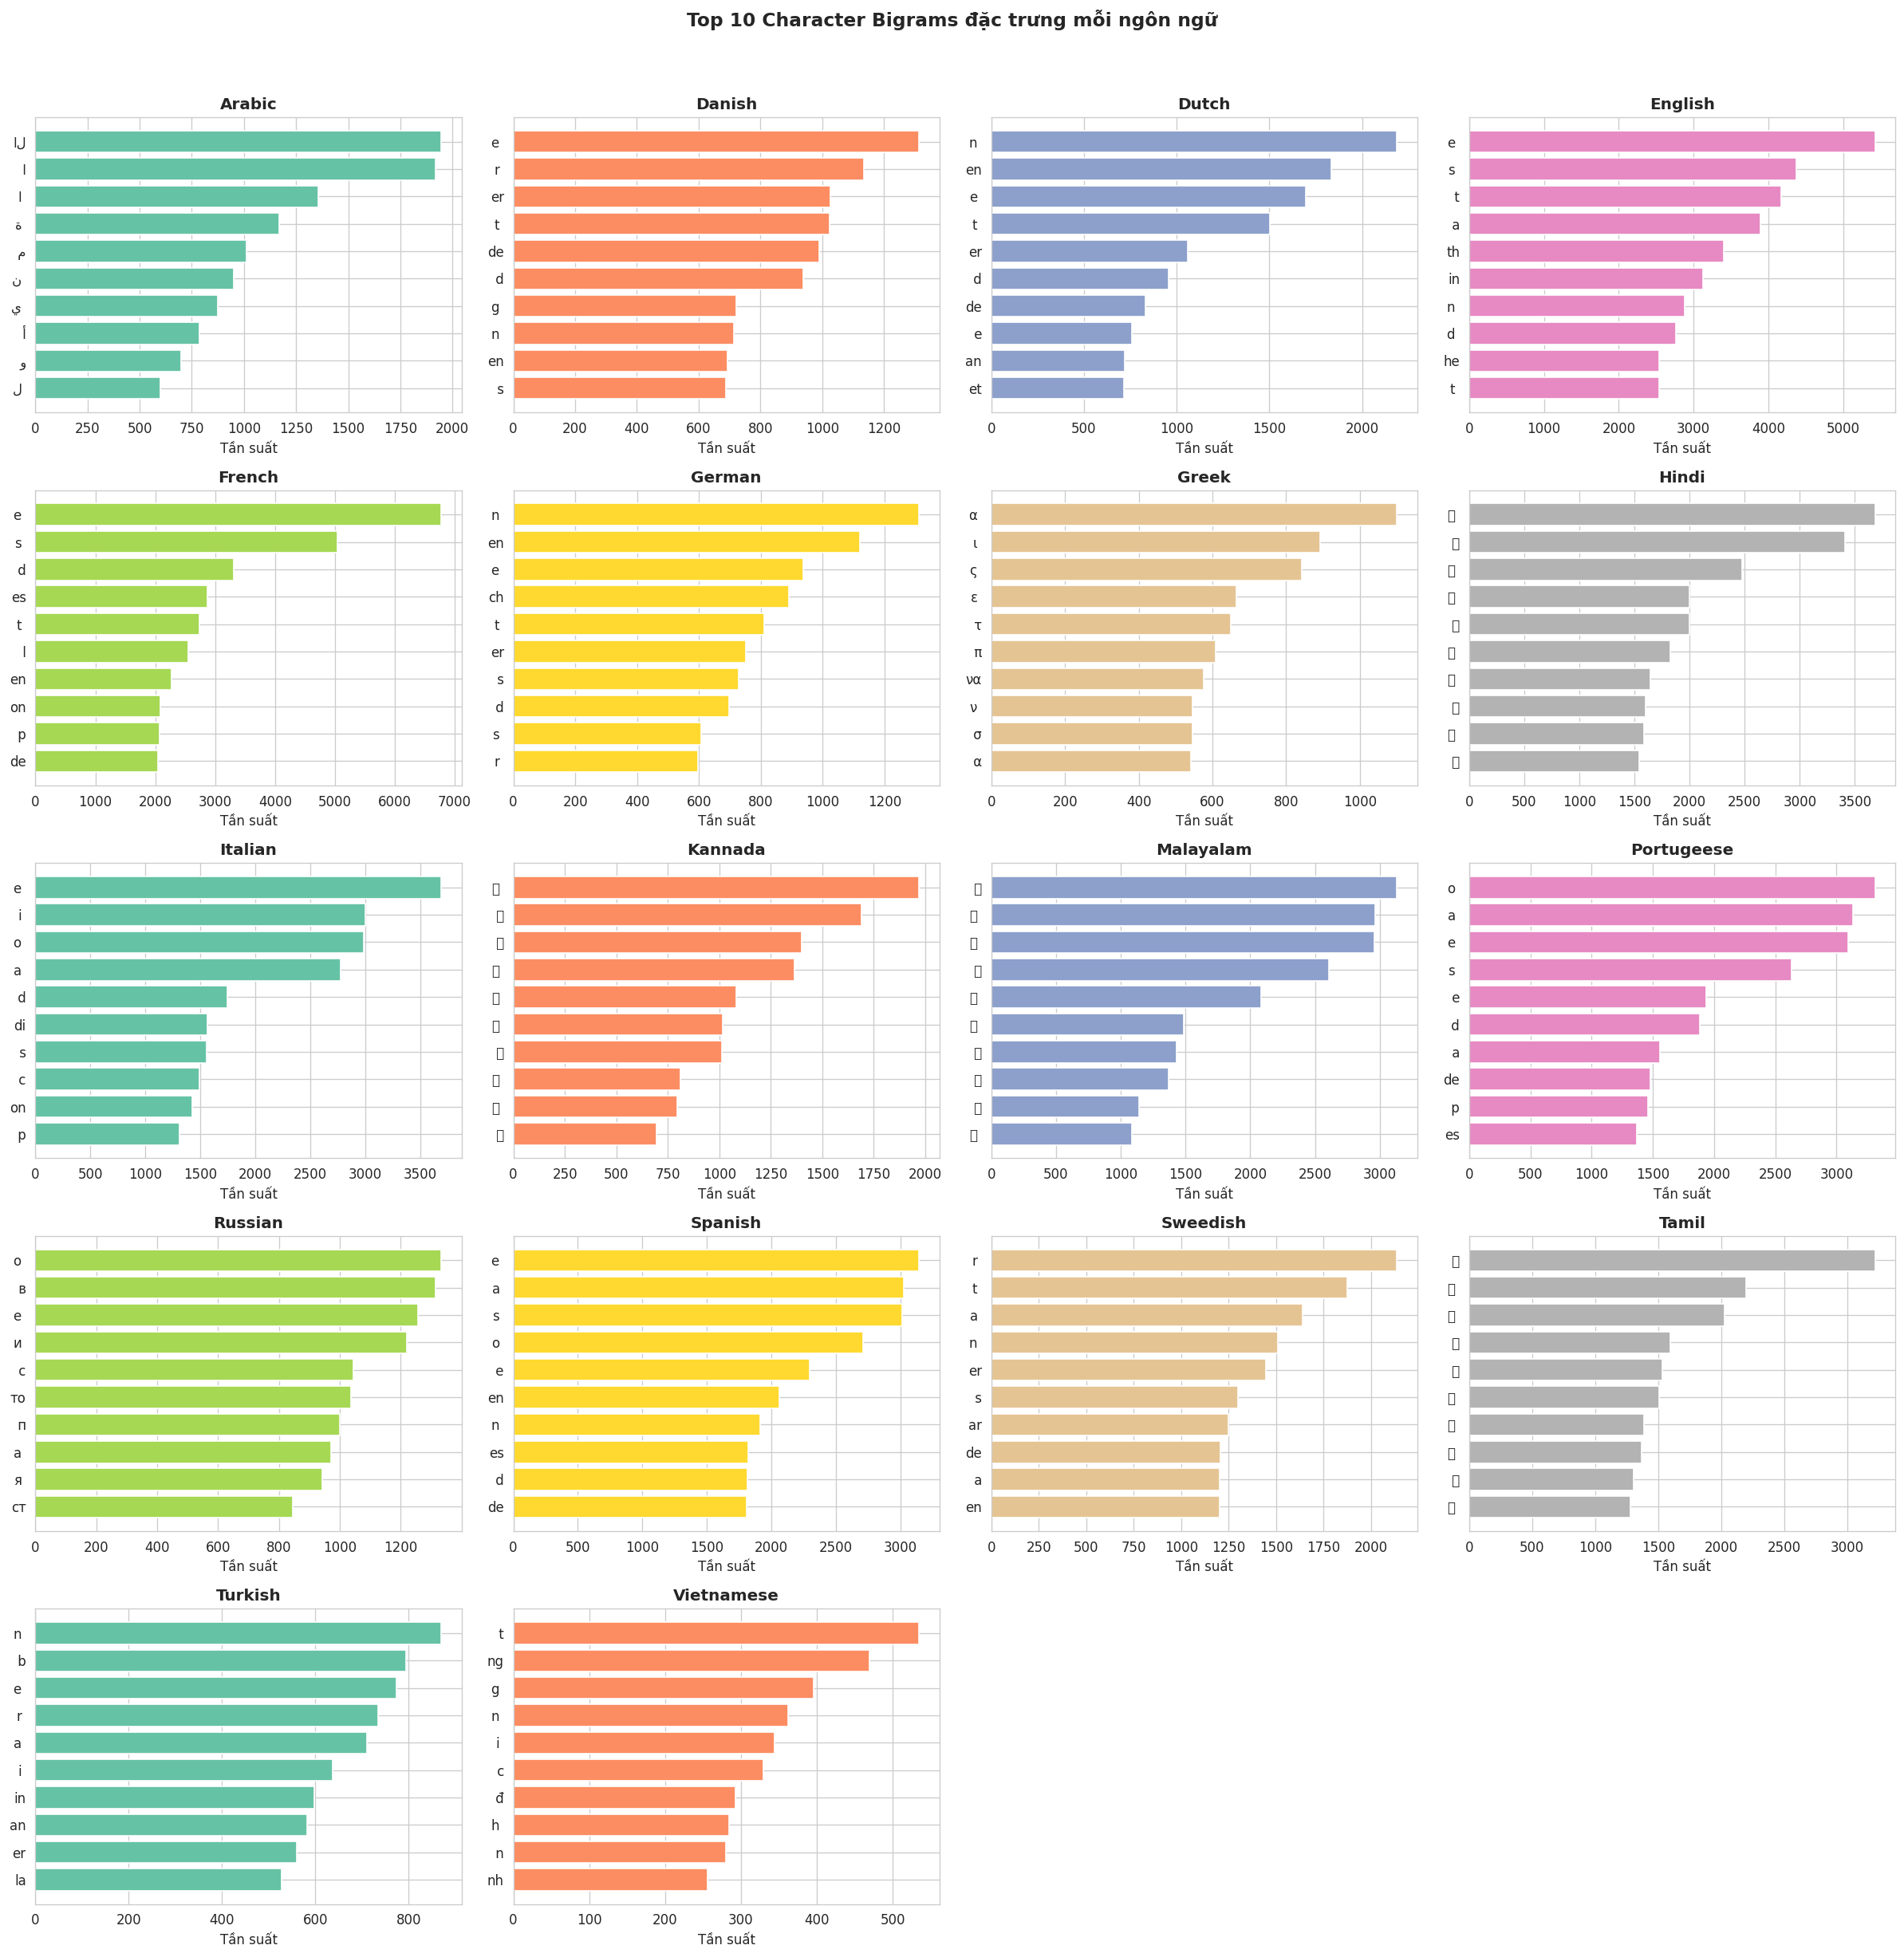

💡 Nhận xét: Mỗi ngôn ngữ có 'dấu vân tay' n-gram hoàn toàn khác nhau!


In [130]:
# ============================================================
# TRỰC QUAN HÓA: Top N-grams đặc trưng mỗi ngôn ngữ
# ============================================================
print("📊 Top 10 Character Bigrams đặc trưng mỗi ngôn ngữ:\n")

n_langs = len(SELECTED_LANGUAGES)
n_cols = 4
n_rows = (n_langs + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for idx, lang in enumerate(SELECTED_LANGUAGES):
    lang_texts = df_filtered[df_filtered['Language'] == lang]['text_clean'].tolist()
    
    # Tạo vectorizer cho ngôn ngữ này
    vec = CountVectorizer(analyzer='char_wb', ngram_range=(2, 2), max_features=15)
    X_lang = vec.fit_transform(lang_texts)
    
    # Tổng tần suất mỗi bigram
    freq = np.asarray(X_lang.sum(axis=0)).flatten()
    vocab = vec.get_feature_names_out()
    top_idx = freq.argsort()[-10:][::-1]
    
    top_ngrams = [vocab[i] for i in top_idx]
    top_freq = [freq[i] for i in top_idx]
    
    color = sns.color_palette('Set2', len(SELECTED_LANGUAGES))[idx]
    axes[idx].barh(top_ngrams[::-1], top_freq[::-1], color=color)
    axes[idx].set_title(f'{lang}', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Tần suất')

# Ẩn các subplot thừa
for idx in range(len(SELECTED_LANGUAGES), len(axes)):
    axes[idx].set_visible(False)
plt.suptitle('Top 10 Character Bigrams đặc trưng mỗi ngôn ngữ', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("💡 Nhận xét: Mỗi ngôn ngữ có 'dấu vân tay' n-gram hoàn toàn khác nhau!")

In [131]:
# ============================================================
# ĐỊNH NGHĨA CÁC PIPELINE THÍ NGHIỆM
# ============================================================

# Vectorizer chung dùng cho tất cả thí nghiệm
TFIDF_CHAR = TfidfVectorizer(
    analyzer='char_wb',     # Character n-grams, không vượt ranh giới từ
    ngram_range=(2, 4),     # Dùng bigram đến 4-gram
    max_features=50000,     # Giới hạn số đặc trưng
    sublinear_tf=True,      # Dùng log(tf) thay vì tf (giảm ảnh hưởng của từ lặp nhiều)
    strip_accents=None,     # QUAN TRỌNG: Giữ lại dấu accent!
)

# Các mô hình cần so sánh
models = {
    "Naive Bayes (Multinomial)": Pipeline([
        ('tfidf', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(2, 4),
            max_features=50000, sublinear_tf=True, strip_accents=None
        )),
        ('clf', MultinomialNB(alpha=0.1))
    ]),
    
    "Naive Bayes (Complement)": Pipeline([
        ('tfidf', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(2, 4),
            max_features=50000, sublinear_tf=True, strip_accents=None
        )),
        ('clf', ComplementNB(alpha=0.1))  # Tốt hơn với imbalanced data
    ]),
    
    "Logistic Regression": Pipeline([
        ('tfidf', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(2, 4),
            max_features=50000, sublinear_tf=True, strip_accents=None
        )),
        ('clf', LogisticRegression(
            max_iter=1000,
            C=5.0,           # Hệ số regularization (C lớn = ít regularize hơn)
            solver='lbfgs',
            multi_class='multinomial'
        ))
    ]),
}

print("✅ Đã định nghĩa", len(models), "pipeline thí nghiệm")

✅ Đã định nghĩa 3 pipeline thí nghiệm


In [132]:
# ============================================================
# HUẤN LUYỆN VÀ ĐÁNH GIÁ TẤT CẢ MÔ HÌNH
# ============================================================
import time

results = {}

for name, pipeline in models.items():
    print(f"\n🚀 Đang huấn luyện: {name}")
    
    # Đo thời gian huấn luyện
    t0 = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - t0
    
    # Dự đoán
    t1 = time.time()
    y_pred = pipeline.predict(X_test)
    infer_time = time.time() - t1
    
    # Tính Accuracy
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = {
        'pipeline': pipeline,
        'y_pred': y_pred,
        'accuracy': acc,
        'train_time': train_time,
        'infer_time': infer_time,
    }
    
    print(f"   ✅ Accuracy: {acc:.4f} | Train: {train_time:.2f}s | Infer: {infer_time*1000:.1f}ms")

print("\n" + "="*60)
print("TỔNG KẾT:".center(60))
print("="*60)
summary = pd.DataFrame([
    {
        'Mô hình': name,
        'Accuracy': f"{r['accuracy']:.4f}",
        'Thời gian train (s)': f"{r['train_time']:.2f}",
        'Thời gian infer (ms)': f"{r['infer_time']*1000:.1f}",
    }
    for name, r in results.items()
])
print(summary.to_string(index=False))


🚀 Đang huấn luyện: Naive Bayes (Multinomial)
   ✅ Accuracy: 0.9916 | Train: 0.92s | Infer: 231.7ms

🚀 Đang huấn luyện: Naive Bayes (Complement)
   ✅ Accuracy: 0.9907 | Train: 1.06s | Infer: 235.7ms

🚀 Đang huấn luyện: Logistic Regression
   ✅ Accuracy: 0.9897 | Train: 9.27s | Infer: 222.4ms

                         TỔNG KẾT:                          
                  Mô hình Accuracy Thời gian train (s) Thời gian infer (ms)
Naive Bayes (Multinomial)   0.9916                0.92                231.7
 Naive Bayes (Complement)   0.9907                1.06                235.7
      Logistic Regression   0.9897                9.27                222.4


In [133]:
# ============================================================
# CHỌN MÔ HÌNH TỐT NHẤT ĐỂ PHÂN TÍCH CHI TIẾT
# ============================================================
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_result = results[best_name]
y_pred_best = best_result['y_pred']

print(f"🏆 Mô hình tốt nhất: {best_name}")
print(f"   Accuracy: {best_result['accuracy']:.4f}\n")

# Classification Report đầy đủ
print("📊 Classification Report (chi tiết từng ngôn ngữ):")
print("-" * 60)
print(classification_report(y_test, y_pred_best))

🏆 Mô hình tốt nhất: Naive Bayes (Multinomial)
   Accuracy: 0.9916

📊 Classification Report (chi tiết từng ngôn ngữ):
------------------------------------------------------------
              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       107
      Danish       1.00      0.93      0.96        85
       Dutch       0.99      0.98      0.99       109
     English       0.98      1.00      0.99       277
      French       1.00      1.00      1.00       203
      German       1.00      0.99      0.99        94
       Greek       1.00      1.00      1.00        73
       Hindi       1.00      1.00      1.00        12
     Italian       0.99      1.00      1.00       139
     Kannada       1.00      1.00      1.00        74
   Malayalam       1.00      1.00      1.00       119
  Portugeese       0.99      0.99      0.99       148
     Russian       1.00      1.00      1.00       138
     Spanish       0.99      0.98      0.99       164
    Sweedis

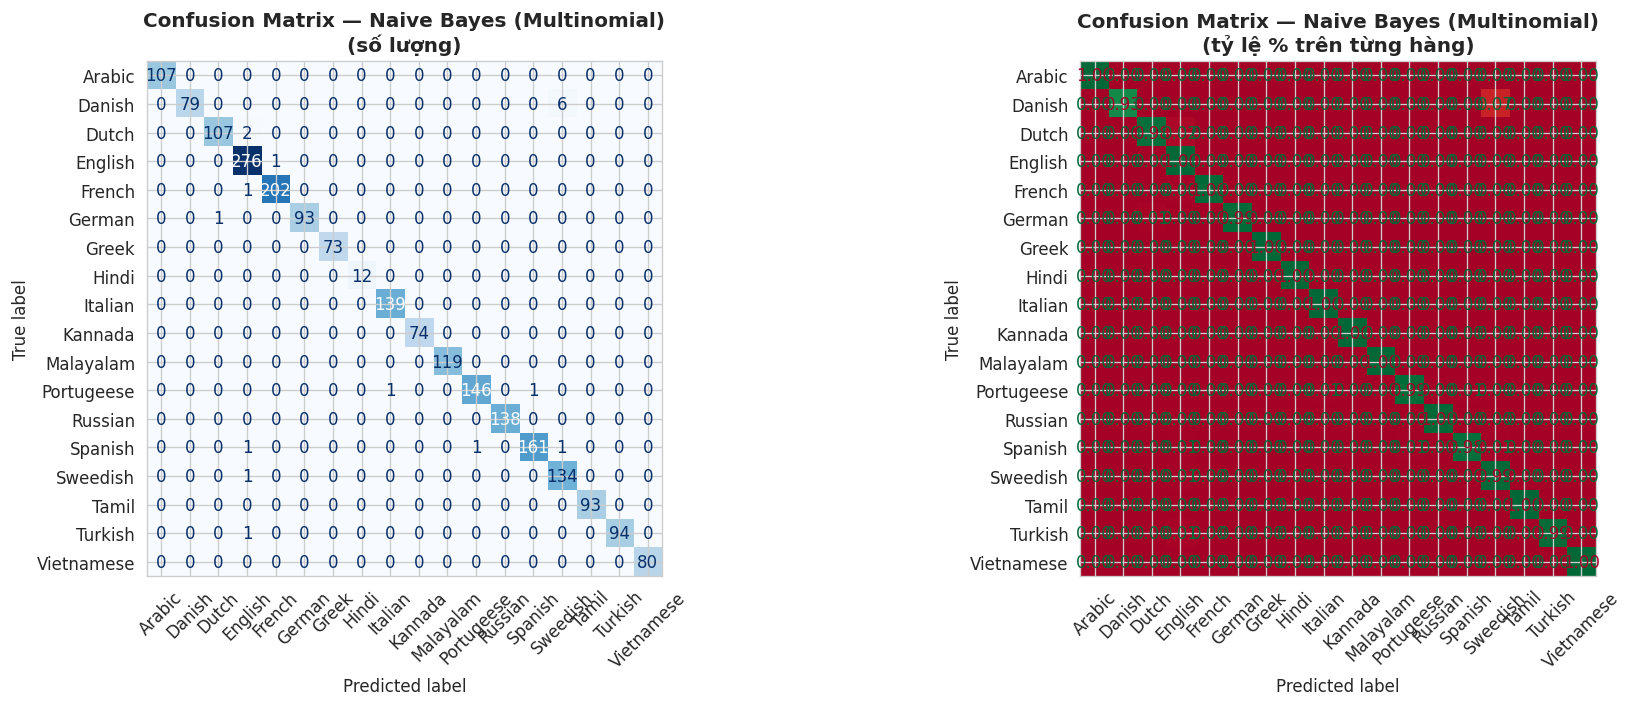

💡 Đọc Confusion Matrix:
   - Đường chéo (xanh đậm) = dự đoán ĐÚNG
   - Ô ngoài đường chéo = dự đoán SAI
   - Ô [hàng A, cột B] = mẫu thực tế là A nhưng bị predict là B


In [134]:
# ============================================================
# CONFUSION MATRIX — Trực quan hóa
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Lấy danh sách nhãn
labels = sorted(df_filtered['Language'].unique())

# Plot 1: Confusion Matrix (số lượng)
cm = confusion_matrix(y_test, y_pred_best, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best_name}\n(số lượng)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Confusion Matrix (tỷ lệ %)
cm_norm = confusion_matrix(y_test, y_pred_best, labels=labels, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
disp2.plot(ax=axes[1], colorbar=False, cmap='RdYlGn', values_format='.2f')
axes[1].set_title(f'Confusion Matrix — {best_name}\n(tỷ lệ % trên từng hàng)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("💡 Đọc Confusion Matrix:")
print("   - Đường chéo (xanh đậm) = dự đoán ĐÚNG")
print("   - Ô ngoài đường chéo = dự đoán SAI")
print("   - Ô [hàng A, cột B] = mẫu thực tế là A nhưng bị predict là B")

In [135]:
# ============================================================
# TẠO DATAFRAME PHÂN TÍCH LỖI
# ============================================================
best_pipeline = best_result['pipeline']

# Tạo DataFrame với kết quả dự đoán
test_df = pd.DataFrame({
    'text_original': df_filtered.loc[X_test.index, 'Text'].values,
    'text_clean': X_test.values,
    'true_label': y_test.values,
    'pred_label': y_pred_best,
})

test_df['is_correct'] = test_df['true_label'] == test_df['pred_label']
test_df['text_length'] = test_df['text_clean'].str.len()

# Tỉ lệ đúng/sai
print(f"✅ Dự đoán đúng: {test_df['is_correct'].sum()} / {len(test_df)} ({test_df['is_correct'].mean():.2%})")
print(f"❌ Dự đoán sai : {(~test_df['is_correct']).sum()} mẫu")

✅ Dự đoán đúng: 2127 / 2145 (99.16%)
❌ Dự đoán sai : 18 mẫu


In [136]:
# Xem các mẫu bị dự đoán SAI
errors = test_df[~test_df['is_correct']].copy()
errors = errors.sort_values('text_length')

print(f"\n🔍 CÁC MẪU BỊ DỰ ĐOÁN SAI ({len(errors)} mẫu):\n")
for _, row in errors.head(15).iterrows():
    print(f"  True: [{row['true_label']:10}] | Pred: [{row['pred_label']:10}] | Độ dài: {row['text_length']}")
    print(f"  Text: {row['text_original'][:100]}")
    print()


🔍 CÁC MẪU BỊ DỰ ĐOÁN SAI (18 mẫu):

  True: [Spanish   ] | Pred: [Sweedish  ] | Độ dài: 5
  Text: venga.

  True: [Danish    ] | Pred: [Sweedish  ] | Độ dài: 6
  Text: Åh gud.

  True: [Danish    ] | Pred: [Sweedish  ] | Độ dài: 6
  Text: Åh gud.

  True: [Portugeese] | Pred: [Spanish   ] | Độ dài: 6
  Text: cuidar.

  True: [Turkish   ] | Pred: [English   ] | Độ dài: 8
  Text: tereddüt.

  True: [Dutch     ] | Pred: [English   ] | Độ dài: 10
  Text: suggesties.

  True: [English   ] | Pred: [French    ] | Độ dài: 10
  Text: permission.

  True: [French    ] | Pred: [English   ] | Độ dài: 11
  Text: suggestions.

  True: [Danish    ] | Pred: [Sweedish  ] | Độ dài: 13
  Text: holde kontakt.

  True: [Danish    ] | Pred: [Sweedish  ] | Độ dài: 14
  Text: rocker du rock?

  True: [German    ] | Pred: [Dutch     ] | Độ dài: 15
  Text: Menschen danken.

  True: [Spanish   ] | Pred: [English   ] | Độ dài: 16
  Text: tu rock you rock?

  True: [Portugeese] | Pred: [Italian   ] | Độ dài: 25
 

In [137]:
# ============================================================
# HÀM DEMO: Nhận diện ngôn ngữ + hiển thị confidence
# ============================================================

def detect_language(text, pipeline, top_k=3):
    """
    Nhận diện ngôn ngữ và trả về top-k ngôn ngữ có xác suất cao nhất.
    
    Args:
        text     : chuỗi văn bản đầu vào
        pipeline : sklearn Pipeline đã huấn luyện
        top_k    : số ngôn ngữ hiển thị
    """
    # Tiền xử lý
    text_clean = preprocess_text(text)
    
    # Lấy xác suất từng ngôn ngữ
    proba = pipeline.predict_proba([text_clean])[0]
    classes = pipeline.classes_
    
    # Sắp xếp theo xác suất giảm dần
    top_indices = proba.argsort()[-top_k:][::-1]
    
    print(f"\n📝 Input  : '{text}'")
    print(f"🔍 Cleaned: '{text_clean}'")
    print(f"\n🏆 Kết quả (Top {top_k}):")
    print(f"{'Rank':<6} {'Ngôn ngữ':<15} {'Xác suất':<12} {'Bar'}")
    print("-" * 55)
    for rank, idx in enumerate(top_indices, 1):
        lang = classes[idx]
        prob = proba[idx]
        bar = '█' * int(prob * 30)
        marker = " ← 🏆" if rank == 1 else ""
        print(f"#{rank:<5} {lang:<15} {prob:.4f} ({prob:.1%})  {bar}{marker}")
    print()


# Lấy pipeline tốt nhất
best_pipeline = results[best_name]['pipeline']

print("=" * 60)
print("DEMO NHẬN DIỆN NGÔN NGỮ".center(60))
print("=" * 60)

                  DEMO NHẬN DIỆN NGÔN NGỮ                   


In [138]:
# ============================================================
# THỬ CÁC CÂU VÍ DỤ
# ============================================================

test_sentences = [
    "My name is Truong Vu and. I love programming in Python!",
    "toi yeu mta",
]

for sentence in test_sentences:
    detect_language(sentence, best_pipeline, top_k=5)
    print("-" * 60)


📝 Input  : 'My name is Truong Vu and. I love programming in Python!'
🔍 Cleaned: 'my name is truong vu and i love programming in python'

🏆 Kết quả (Top 5):
Rank   Ngôn ngữ        Xác suất     Bar
-------------------------------------------------------
#1     English         0.9971 (99.7%)  █████████████████████████████ ← 🏆
#2     Italian         0.0017 (0.2%)  
#3     French          0.0004 (0.0%)  
#4     Sweedish        0.0003 (0.0%)  
#5     Dutch           0.0003 (0.0%)  

------------------------------------------------------------

📝 Input  : 'toi yeu mta'
🔍 Cleaned: 'toi yeu mta'

🏆 Kết quả (Top 5):
Rank   Ngôn ngữ        Xác suất     Bar
-------------------------------------------------------
#1     French          0.6779 (67.8%)  ████████████████████ ← 🏆
#2     Portugeese      0.1294 (12.9%)  ███
#3     English         0.0721 (7.2%)  ██
#4     Italian         0.0300 (3.0%)  
#5     Sweedish        0.0291 (2.9%)  

------------------------------------------------------------


In [139]:
# ============================================================
# 🎮 INTERACTIVE: Nhập câu tùy ý
# ============================================================

print("🎮 Nhập câu bất kỳ để nhận diện ngôn ngữ:")
print("   (nhập 'quit' để thoát)\n")

while True:
    user_input = input(">>> Nhập văn bản: ")
    if user_input.lower() in ['quit', 'q', 'exit', '']:
        print("👋 Thoát demo.")
        break
    detect_language(user_input, best_pipeline, top_k=5)

🎮 Nhập câu bất kỳ để nhận diện ngôn ngữ:
   (nhập 'quit' để thoát)

👋 Thoát demo.


In [140]:
# ============================================================
# BONUS: Lưu model để dùng lại
# ============================================================
import joblib

# Lưu pipeline tốt nhất
joblib.dump(best_pipeline, 'language_detector.pkl')
print(f"✅ Đã lưu model: 'language_detector.pkl'")

# Load lại và test
loaded_model = joblib.load('language_detector.pkl')
test_text = "Bonjour, je suis ravi de vous rencontrer."
prediction = loaded_model.predict([preprocess_text(test_text)])[0]
print(f"\n🧪 Test load model:")
print(f"   Input: '{test_text}'")
print(f"   Predict: {prediction}")

✅ Đã lưu model: 'language_detector.pkl'

🧪 Test load model:
   Input: 'Bonjour, je suis ravi de vous rencontrer.'
   Predict: French
